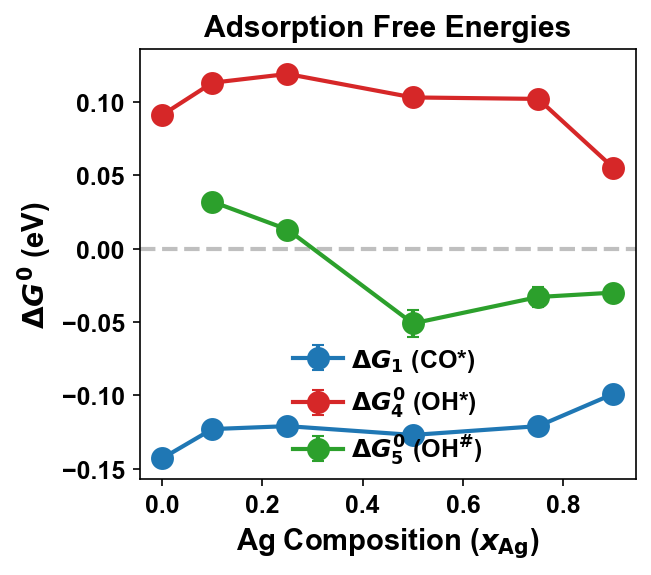

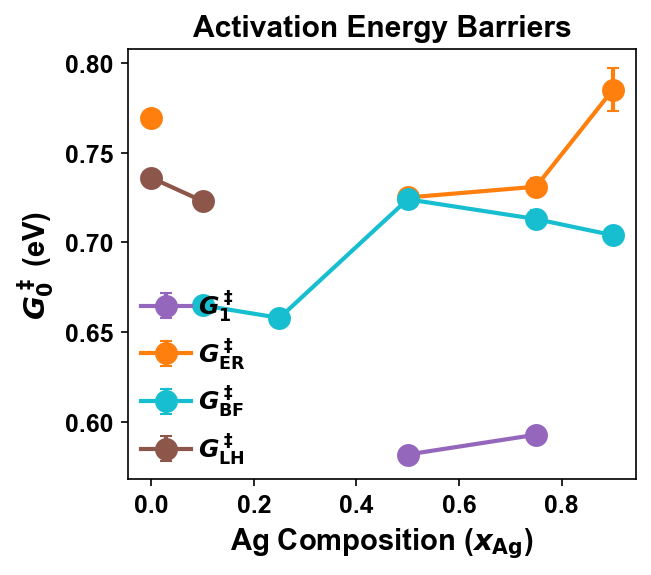

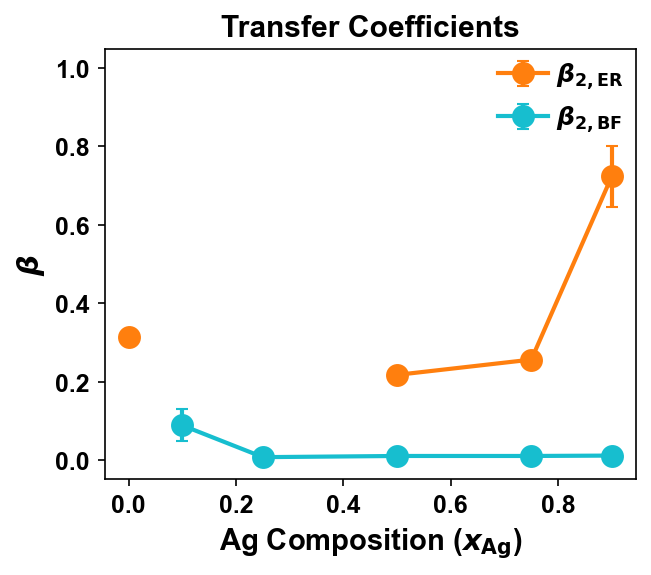

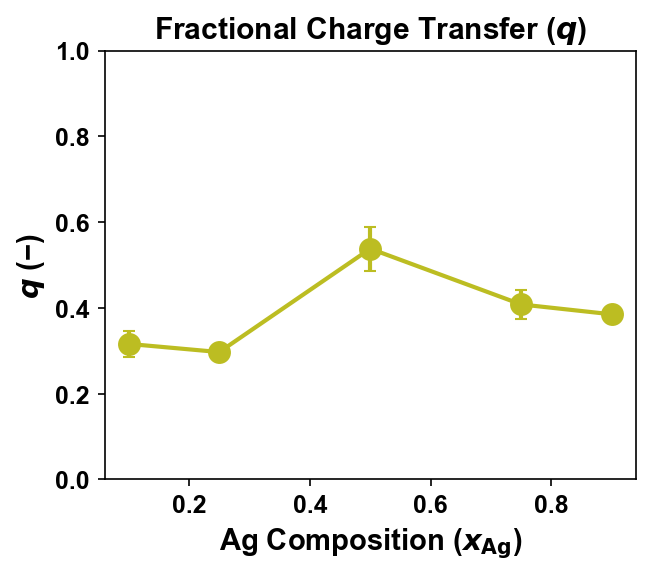

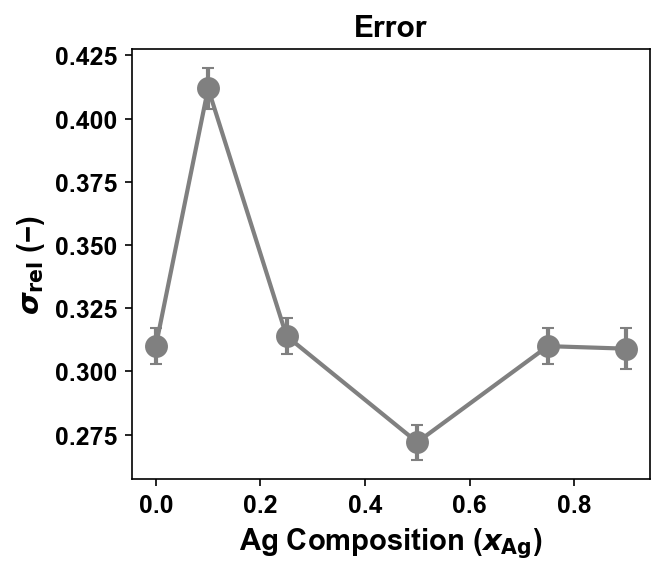

In [21]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
utils_path = r"C:\Users\awast\OneDrive\Desktop\MKM"
sys.path.append(utils_path)
import _plotting_defaults

Ag_comp = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90])

data = {
    'Ag_comp': Ag_comp,
    'Model': ['ER_LH', 'BF_LH', 'BF', 'CO_BF_ER', 'CO_BF_ER', 'BF_ER'],
    
    # Adsorption Free Energies (eV)
    'deltaG1_0_mean': [-0.143, -0.123, -0.121, -0.127, -0.121, -0.099],
    'deltaG1_0_sd':   [ 0.001,  0.001,  0.001,  0.001,  0.001,  0.001],
    'deltaG4_0_mean': [ 0.091,  0.113,  0.119,  0.103,  0.102,  0.055],
    'deltaG4_0_sd':   [ 0.002,  0.005,  0.004,  0.003,  0.003,  0.003],
    'deltaG5_0_mean': [np.nan,  0.032,  0.013, -0.051, -0.033, -0.030],
    'deltaG5_0_sd':   [np.nan,  0.005,  0.002,  0.009,  0.007,  0.003],
    
    # Interfacial Site Fraction
    'q_mean':         [np.nan,  0.316,  0.297,  0.538,  0.408,  0.385],
    'q_sd':           [np.nan,  0.031,  0.006,  0.051,  0.033,  0.011],
    
    # Activation Energies (eV)
    'Gact1_0_mean':   [np.nan, np.nan, np.nan,  0.582,  0.593, np.nan],
    'Gact1_0_sd':     [np.nan, np.nan, np.nan,  0.003,  0.003, np.nan],
    'Gact2_ER_0_mean':[ 0.769, np.nan, np.nan,  0.725,  0.731,  0.785],
    'Gact2_ER_0_sd':  [ 0.001, np.nan, np.nan,  0.002,  0.005,  0.012],
    'Gact2_BF_0_mean':[np.nan,  0.665,  0.658,  0.724,  0.713,  0.704],
    'Gact2_BF_0_sd':  [np.nan,  0.004,  0.002,  0.004,  0.005,  0.002],
    'Gact2_LH_0_mean':[ 0.736,  0.723, np.nan, np.nan, np.nan, np.nan],
    'Gact2_LH_0_sd':  [ 0.003,  0.004, np.nan, np.nan, np.nan, np.nan],
    
    # Transfer Coefficients (-)
    'beta_2_ER_mean': [ 0.313, np.nan, np.nan,  0.217,  0.256,  0.724],
    'beta_2_ER_sd':   [ 0.002, np.nan, np.nan,  0.005,  0.014,  0.078],
    'beta_2_BF_mean': [np.nan,  0.088,  0.007,  0.010,  0.010,  0.011],
    'beta_2_BF_sd':   [np.nan,  0.041,  0.006,  0.011,  0.009,  0.010],
    
    # Dispersion Error (-)
    'sigma_rel_mean': [ 0.310,  0.412,  0.314,  0.272,  0.310,  0.309],
    'sigma_rel_sd':   [ 0.007,  0.008,  0.007,  0.007,  0.007,  0.008]
}

plt.rcParams['figure.dpi'] = 150 
df = pd.DataFrame(data)
figsize = (4.5, 4)
fmt = dict(marker='o')

# 1. Adsorption Free Energies
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(df['Ag_comp'], df['deltaG1_0_mean'], yerr=df['deltaG1_0_sd'], label=r'$\Delta G_{1}$ (CO*)', color='tab:blue', **fmt)
ax.errorbar(df['Ag_comp'], df['deltaG4_0_mean'], yerr=df['deltaG4_0_sd'], label=r'$\Delta G_{4}^0$ (OH*)', color='tab:red', **fmt)
ax.errorbar(df['Ag_comp'], df['deltaG5_0_mean'], yerr=df['deltaG5_0_sd'], label=r'$\Delta G_{5}^0$ (OH$^\#$)', color='tab:green', **fmt)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'Ag Composition ($x_{\mathrm{Ag}}$)', fontweight='bold') # Added explicit x-label
ax.set_ylabel(r'$\Delta G^0$ (eV)', fontweight='bold')
ax.set_title('Adsorption Free Energies', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 2. Activation Energy Barriers
fig, ax = plt.subplots(figsize=figsize) 
ax.errorbar(df['Ag_comp'], df['Gact1_0_mean'], yerr=df['Gact1_0_sd'], label=r'$G^\ddagger_{1}$', color='tab:purple', **fmt)
ax.errorbar(df['Ag_comp'], df['Gact2_ER_0_mean'], yerr=df['Gact2_ER_0_sd'], label=r'$G^\ddagger_{\mathrm{ER}}$', color='tab:orange', **fmt)
ax.errorbar(df['Ag_comp'], df['Gact2_BF_0_mean'], yerr=df['Gact2_BF_0_sd'], label=r'$G^\ddagger_{\mathrm{BF}}$', color='tab:cyan', **fmt)
ax.errorbar(df['Ag_comp'], df['Gact2_LH_0_mean'], yerr=df['Gact2_LH_0_sd'], label=r'$G^\ddagger_{\mathrm{LH}}$', color='tab:brown', **fmt)
ax.set_xlabel(r'Ag Composition ($x_{\mathrm{Ag}}$)', fontweight='bold') # Added explicit x-label
ax.set_ylabel(r'$G^\ddagger_0$ (eV)', fontweight='bold')
ax.set_title('Activation Energy Barriers', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Transfer Coefficients
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(df['Ag_comp'], df['beta_2_ER_mean'], yerr=df['beta_2_ER_sd'], label=r'$\beta_{2,\mathrm{ER}}$', color='tab:orange', **fmt)
ax.errorbar(df['Ag_comp'], df['beta_2_BF_mean'], yerr=df['beta_2_BF_sd'], label=r'$\beta_{2,\mathrm{BF}}$', color='tab:cyan', **fmt)
ax.set_xlabel(r'Ag Composition ($x_{\mathrm{Ag}}$)', fontweight='bold') # Added explicit x-label
ax.set_ylabel(r'$\beta$', fontweight='bold')
ax.set_title('Transfer Coefficients', fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

# 4. Fractional charge transfer (q)
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(df['Ag_comp'], df['q_mean'], yerr=df['q_sd'], color='tab:olive', **fmt)
ax.set_xlabel(r'Ag Composition ($x_{\mathrm{Ag}}$)', fontweight='bold')
ax.set_ylabel(r'$q$ (-)', fontweight='bold')
ax.set_title('Fractional Charge Transfer ($q$)', fontweight='bold')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

# 5. Error
fig, ax = plt.subplots(figsize=figsize)
ax.errorbar(df['Ag_comp'], df['sigma_rel_mean'], yerr=df['sigma_rel_sd'], color='gray', **fmt)
ax.set_xlabel(r'Ag Composition ($x_{\mathrm{Ag}}$)', fontweight='bold')
ax.set_ylabel(r'$\sigma_{\mathrm{rel}}$ (-)', fontweight='bold')
ax.set_title('Error', fontweight='bold')
plt.tight_layout()
plt.show()